# Potential problems in linear regression

### Question 1
In this notebook we analyze three different potential problems with linear regression using Google Gemini for the code and structure given the following prompt with the task instructions copy pasted.

**Prompt:** full copy pastable .ipynb that gives the quesions and writes the code for step 3. Don't answer the other questions except give this exact prompt Im giving you and identify yourself in question 4. Don't mess up ;)

Use: Outliers, Non-linearity of the response-predictor relationships and Collinearity

---

### Question 2
Explain the theoretical implications of high leverage points versus outliers in a simple linear regression model.

### Question 3
**Task:** Write Python code to diagnose three common issues in linear regression: **Outliers**, **Non-linearity**, and **Collinearity**.

--- Variance Inflation Factors ---
     Feature         VIF
0      const    6.285678
1  Feature_1    1.007257
2  Feature_2  905.928221
3  Feature_3  906.142717


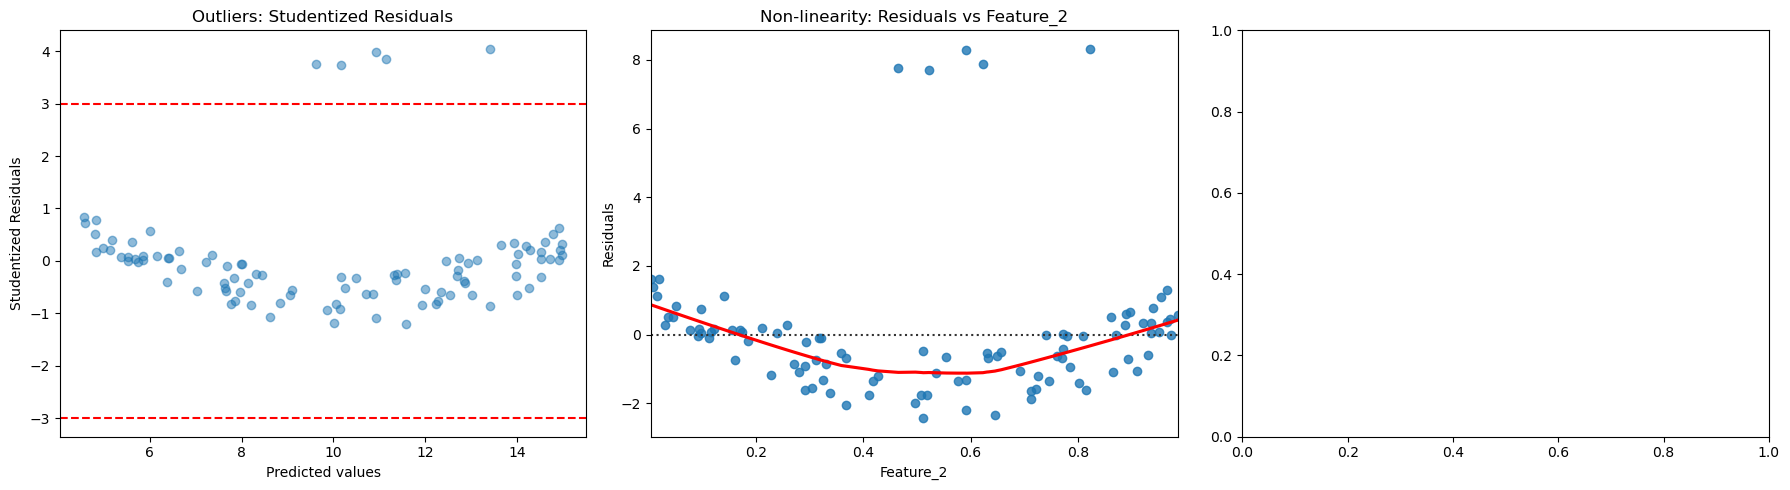

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Setup: Generating dummy data with built-in issues
np.random.seed(42)
X = np.random.rand(100, 3)
X[:, 2] = X[:, 1] * 0.95 + np.random.normal(0, 0.01, 100) # Creating Collinearity
y = 5 + 2*X[:, 0] + 10*X[:, 1]**2 + np.random.normal(0, 0.1, 100) # Non-linear relationship
y[95:] += 10 # Adding Outliers

df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2', 'Feature_3'])
X_const = sm.add_constant(df)
model = sm.OLS(y, X_const).fit()

## --- DIAGNOSTICS ---

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# A. Outliers (Studentized Residuals)
influence = model.get_influence()
resid_student = influence.resid_studentized_internal
axes[0].scatter(model.predict(), resid_student, alpha=0.5)
axes[0].axhline(y=3, color='r', linestyle='--')
axes[0].axhline(y=-3, color='r', linestyle='--')
axes[0].set_title('Outliers: Studentized Residuals')
axes[0].set_xlabel('Predicted values')
axes[0].set_ylabel('Studentized Residuals')

# B. Non-linearity (Residuals vs Predictor)
sns.residplot(x=df['Feature_2'], y=y, lowess=True, ax=axes[1], line_kws={'color': 'red'})
axes[1].set_title('Non-linearity: Residuals vs Feature_2')
axes[1].set_xlabel('Feature_2')
axes[1].set_ylabel('Residuals')

# C. Collinearity (Variance Inflation Factor)
vif_data = pd.DataFrame()
vif_data["Feature"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(len(X_const.columns))]
print("--- Variance Inflation Factors ---")
print(vif_data)

plt.tight_layout()
plt.show()

!
](attachment:image.png)

### Question 4
**Who are you?**

I am Gemini, an AI model developed by Google.